Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Load Dataset

In [2]:
df=pd.read_csv(r"C:\Users\Shilpa\OneDrive\Desktop\Symptom-to-Disease Chatbot\dataset.csv")

In [3]:
df.head()

,Disease,Symptom_0,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16
0,AIDS,muscle_wasting,patches_in_throat,high_fever,extra_marital_contacts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AIDS,patches_in_throat,high_fever,extra_marital_contacts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AIDS,muscle_wasting,high_fever,extra_marital_contacts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AIDS,muscle_wasting,patches_in_throat,extra_marital_contacts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AIDS,muscle_wasting,patches_in_throat,high_fever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     313 non-null    object
 1   Symptom_0   313 non-null    object
 2   Symptom_1   313 non-null    object
 3   Symptom_2   313 non-null    object
 4   Symptom_3   281 non-null    object
 5   Symptom_4   234 non-null    object
 6   Symptom_5   186 non-null    object
 7   Symptom_6   158 non-null    object
 8   Symptom_7   140 non-null    object
 9   Symptom_8   120 non-null    object
 10  Symptom_9   110 non-null    object
 11  Symptom_10  68 non-null     object
 12  Symptom_11  47 non-null     object
 13  Symptom_12  30 non-null     object
 14  Symptom_13  19 non-null     object
 15  Symptom_14  18 non-null     object
 16  Symptom_15  10 non-null     object
 17  Symptom_16  1 non-null      object
dtypes: object(18)
memory usage: 44.1+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Disease         0
Symptom_0       0
Symptom_1       0
Symptom_2       0
Symptom_3      32
Symptom_4      79
Symptom_5     127
Symptom_6     155
Symptom_7     173
Symptom_8     193
Symptom_9     203
Symptom_10    245
Symptom_11    266
Symptom_12    283
Symptom_13    294
Symptom_14    295
Symptom_15    303
Symptom_16    312
dtype: int64

In [7]:
df = df.fillna("")

In [8]:
df.isnull().sum()

Disease       0
Symptom_0     0
Symptom_1     0
Symptom_2     0
Symptom_3     0
Symptom_4     0
Symptom_5     0
Symptom_6     0
Symptom_7     0
Symptom_8     0
Symptom_9     0
Symptom_10    0
Symptom_11    0
Symptom_12    0
Symptom_13    0
Symptom_14    0
Symptom_15    0
Symptom_16    0
dtype: int64

Preprocess Data

In [9]:
symptom_cols = [col for col in df.columns if "Symptom_" in col]

df["symptoms"] = df[symptom_cols].values.tolist()

In [10]:
df["symptoms"] = df["symptoms"].apply(
    lambda x: [i.strip() for i in x if i not in ["", "None"]]
)

In [11]:
print(df.columns)

Index(['Disease', 'Symptom_0', 'Symptom_1', 'Symptom_2', 'Symptom_3',
       'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8',
       'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13',
       'Symptom_14', 'Symptom_15', 'Symptom_16', 'symptoms'],
      dtype='object')


Encode Features

In [12]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

symptom_matrix = pd.DataFrame(
    mlb.fit_transform(df["symptoms"]),
    columns=mlb.classes_
)

df = pd.concat([df, symptom_matrix], axis=1)

In [13]:
print(df["symptoms"].head())

0    [muscle_wasting, patches_in_throat, high_fever...
1    [patches_in_throat, high_fever, extra_marital_...
2    [muscle_wasting, high_fever, extra_marital_con...
3    [muscle_wasting, patches_in_throat, extra_mari...
4      [muscle_wasting, patches_in_throat, high_fever]
Name: symptoms, dtype: object


In [14]:
X = symptom_matrix
y = df["Disease"]

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# -------------------------
# 1. Decision Tree
# -------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
acc1 = accuracy_score(y_test, dt_pred)

# -------------------------
# 3. Naive Bayes
# -------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
acc3 = accuracy_score(y_test, nb_pred)

# -------------------------
# 4. KNN
# -------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
acc4 = accuracy_score(y_test, knn_pred)

# -------------------------
# Print Results
# -------------------------
print("Decision Tree Accuracy:", acc1)
print("Naive Bayes Accuracy:", acc3)
print("KNN Accuracy:", acc4)

Decision Tree Accuracy: 0.6666666666666666
Naive Bayes Accuracy: 1.0
KNN Accuracy: 1.0


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
acc2 = accuracy_score(y_test, rf_pred)
print("Random Forest:", acc2)

Random Forest: 0.8888888888888888


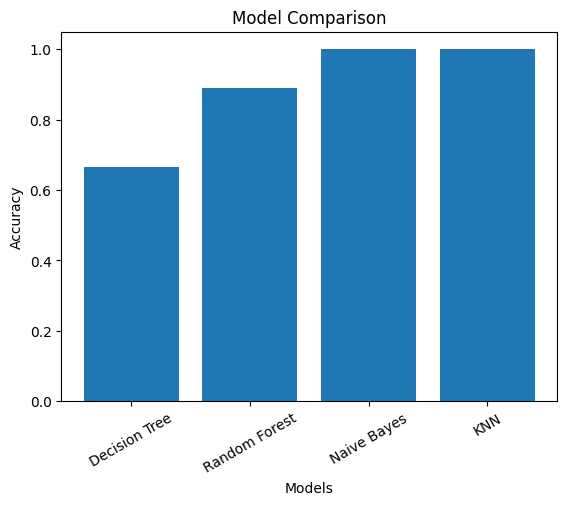

In [19]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest', 'Naive Bayes', 'KNN']
accuracies = [acc1, acc2, acc3, acc4]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

Save Model

In [20]:
import joblib

joblib.dump(rf_model, "disease_model.pkl")
joblib.dump(mlb, "mlb.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

Prediction Function (TOP 1 with confidence)

In [21]:
def predict_disease(symptoms):
    input_data = [0] * len(mlb.classes_)

    for symptom in symptoms:
        if symptom in mlb.classes_:
            index = list(mlb.classes_).index(symptom)
            input_data[index] = 1

    input_df = pd.DataFrame([input_data], columns=mlb.classes_)

    prediction = rf_model.predict(input_df)
    return le.inverse_transform(prediction)[0]

In [23]:
user_input = input("Enter symptoms (comma separated): ")
symptoms = [s.strip() for s in user_input.split(",")]

result = predict_disease(symptoms)
print("You may have:", result)

Enter symptoms (comma separated):  head ache


You may have: Hepatitis C


In [24]:
y_pred = rf_model.predict(X_test)

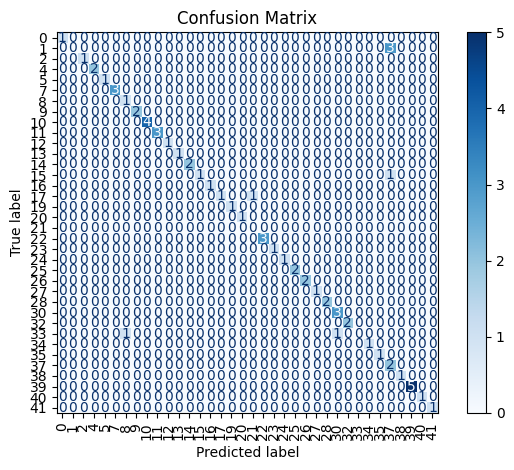

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=90
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

“The confusion matrix shows that most predictions lie along the diagonal, indicating that the model is accurately classifying diseases. 
The normalized version helps visualize performance in percentage terms, making it easier to compare across classes.”

In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print(scores)
print("Mean accuracy:", scores.mean())

[0.98412698 1.         1.         0.98387097 0.96774194]
Mean accuracy: 0.987147977470558


In [27]:
disease_info = {
    "AIDS": {
        "description": "Weakens immune system",
        "precautions": ["Avoid unsafe contact", "Regular testing"]
    },
    "Flu": {
        "description": "Viral infection",
        "precautions": ["Rest", "Drink fluids"]
    }
}

Prediction Function (TOP 3 diseases)

In [28]:
def predict_disease_full(symptoms):
    input_data = [0] * len(mlb.classes_)

    for symptom in symptoms:
        if symptom in mlb.classes_:
            index = list(mlb.classes_).index(symptom)
            input_data[index] = 1

    input_df = pd.DataFrame([input_data], columns=mlb.classes_)

    probs = rf_model.predict_proba(input_df)[0]
    top3 = probs.argsort()[-3:][::-1]

    diseases = le.inverse_transform(top3)
    confidence = probs[top3]

    return list(zip(diseases, confidence))

In [35]:
user_input = input("Enter symptoms (comma separated): ")
symptoms = [s.strip().lower().replace(" ", "_") for s in user_input.split(",")]

print("\n----- Disease Prediction Result -----\n")

results = predict_disease_full(symptoms)

for disease, conf in results:
    print(f"{disease} ({conf*100:.2f}%)")

Enter symptoms (comma separated):  cough, cold, throat irritation



----- Disease Prediction Result -----

Common Cold (6.18%)
Bronchial Asthma (5.45%)
Covid (4.94%)


In [33]:
def chatbot():
    print("🤖 Disease Prediction Chatbot")
    print("Type 'exit' to stop\n")

    while True:
        user_input = input("Enter symptoms (comma separated): ")

        if user_input.lower() == "exit":
            print("Goodbye 👋")
            break

        symptoms = [s.strip().lower().replace(" ", "_") for s in user_input.split(",")]

        results = predict_disease_full(symptoms)

        print("\nTop Predictions:\n")

        for disease, conf in results:
            print(f"{disease} ({conf*100:.2f}%)")

            if disease in disease_info:
                print("Description:", disease_info[disease]["description"])
                print("Precautions:", ", ".join(disease_info[disease]["precautions"]))

            print("-" * 30)

In [34]:
chatbot()

🤖 Disease Prediction Chatbot
Type 'exit' to stop



Enter symptoms (comma separated):  cough, cold, throat irritation



Top Predictions:

Common Cold (6.18%)
------------------------------
Bronchial Asthma (5.45%)
------------------------------
Covid (4.94%)
------------------------------


Enter symptoms (comma separated):  cough, cold, throat irritation



Top Predictions:

Common Cold (6.18%)
------------------------------
Bronchial Asthma (5.45%)
------------------------------
Covid (4.94%)
------------------------------


Enter symptoms (comma separated):  exit


Goodbye 👋
